# 📈 Sales Prediction using Python — CodeAlpha Data Science Internship (Task 4)

**Goal:** Predict product sales based on advertising spend across three channels — TV, Radio, and Newspaper — and understand which channel drives sales the most.

**Dataset:** `Advertising.csv` — 200 records of advertising budgets (in thousands of dollars) and resulting sales (in thousands of units).

**Steps:**
1. Data Load & Cleaning
2. Exploratory Data Analysis (EDA)
3. Train/Test Split
4. Model Training & Comparison (Linear Regression vs Random Forest)
5. Evaluation (R², MAE, RMSE)
6. Feature Impact Analysis & Business Insights


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
%matplotlib inline

## 2. Load & Clean the Data
The first column is just a row index with no name, so we drop it.

In [2]:
df = pd.read_csv('data/Advertising.csv')
df.drop(df.columns[0], axis=1, inplace=True)
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [5]:
# Check for missing values
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

## 3. Exploratory Data Analysis (EDA)

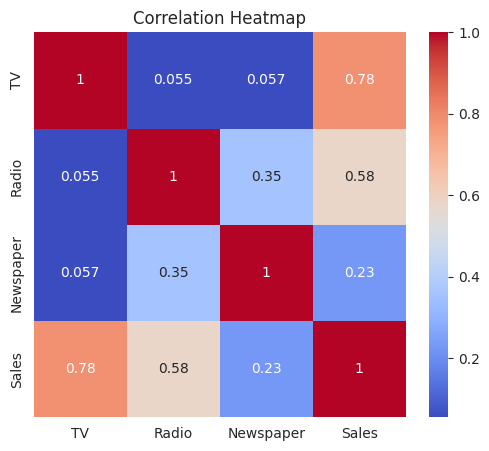

In [6]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('plots/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

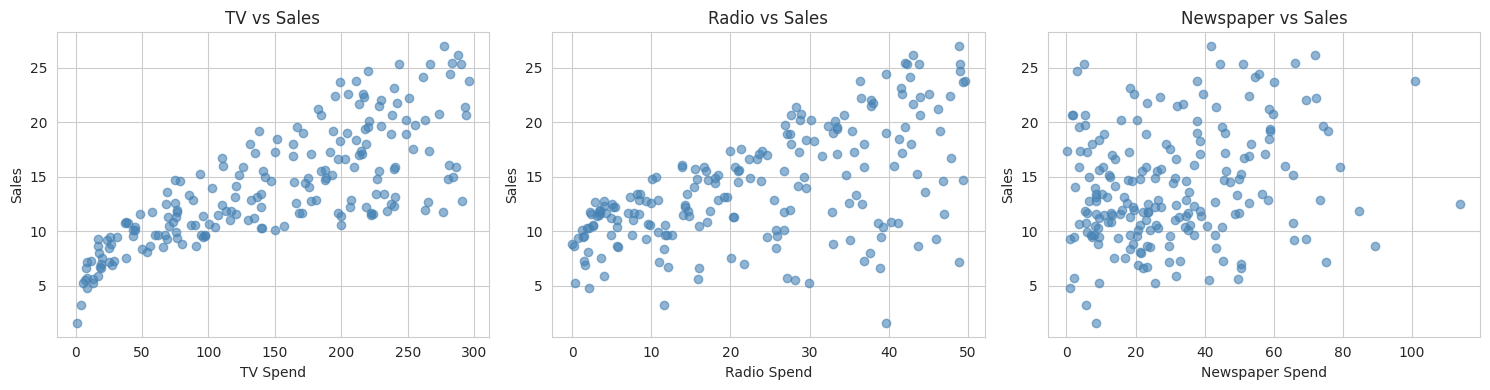

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['TV', 'Radio', 'Newspaper']):
    ax.scatter(df[col], df['Sales'], alpha=0.6, color='steelblue')
    ax.set_xlabel(f'{col} Spend')
    ax.set_ylabel('Sales')
    ax.set_title(f'{col} vs Sales')
plt.tight_layout()
plt.savefig('plots/scatter_features.png', dpi=100, bbox_inches='tight')
plt.show()

**Observation:** TV spend shows the strongest linear correlation with Sales (correlation ≈ 0.78), Radio is moderately correlated (≈ 0.58), and Newspaper has a weak correlation (≈ 0.23). This already hints that Newspaper advertising may not be a strong driver of sales.

## 4. Train/Test Split

In [8]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (160, 3) | Test shape: (40, 3)


## 5. Model Training & Comparison
We train two models — a simple, interpretable Linear Regression and a more flexible Random Forest Regressor — and compare their performance.

In [9]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
    print(f"{name} -> R2: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

Linear Regression -> R2: 0.8994 | MAE: 1.4608 | RMSE: 1.7816
Random Forest -> R2: 0.9813 | MAE: 0.6201 | RMSE: 0.7686


## 6. Interpreting the Linear Regression Coefficients
Linear Regression coefficients tell us how much Sales change per unit increase in advertising spend on each channel (holding the others constant).

Intercept: 2.9791

Coefficients:
Radio        0.189195
TV           0.044730
Newspaper    0.002761
dtype: float64


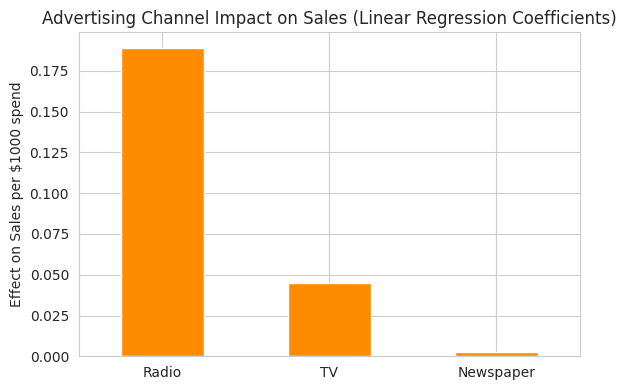

In [10]:
lr = models['Linear Regression']
coef_df = pd.Series(lr.coef_, index=X.columns).sort_values(ascending=False)

print("Intercept:", round(lr.intercept_, 4))
print("\nCoefficients:")
print(coef_df)

plt.figure(figsize=(6,4))
coef_df.plot(kind='bar', color='darkorange')
plt.ylabel('Effect on Sales per $1000 spend')
plt.title('Advertising Channel Impact on Sales (Linear Regression Coefficients)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plots/feature_impact.png', dpi=100, bbox_inches='tight')
plt.show()

**Interpretation:** Every extra $1000 spent on **Radio** boosts sales the most per dollar spent, followed by **TV**. **Newspaper** spend has almost no measurable effect on sales in this model — its coefficient is close to zero.

## 7. Best Model — Actual vs Predicted

Best model: Random Forest | R2: 0.9813


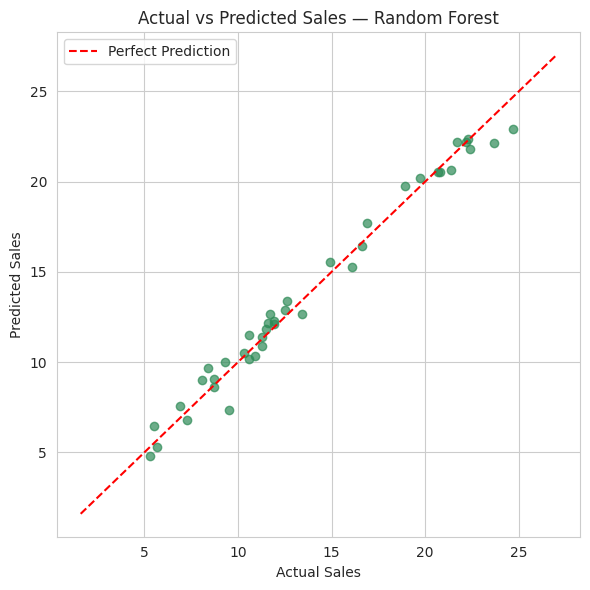

In [11]:
best_name = max(results, key=lambda k: results[k]['R2'])
best_model = models[best_name]
print("Best model:", best_name, "| R2:", round(results[best_name]['R2'], 4))

pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.7, color='seagreen')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title(f'Actual vs Predicted Sales — {best_name}')
plt.legend()
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Conclusion & Business Insights

1. **Random Forest outperformed Linear Regression** (R² ≈ 0.98 vs ≈ 0.90), suggesting some non-linear relationship between advertising spend and sales that a simple linear model can't fully capture.
2. **TV and Radio are the strongest sales drivers.** TV has the highest raw correlation with sales, while Radio has the highest marginal impact per dollar spent (based on the linear coefficients).
3. **Newspaper advertising shows minimal impact** on sales — its coefficient is near zero and its correlation with sales is weak. Budget currently allocated to newspaper ads could likely be reallocated to TV or Radio for better returns.
4. **Actionable takeaway:** For marketing budget optimization, prioritizing TV and Radio spend (especially Radio, given its efficiency per dollar) is likely to yield a better sales lift than Newspaper spend.

**Possible next steps:** Try polynomial/interaction features (e.g., TV × Radio) to see if combined channel effects improve the linear model, or tune Random Forest hyperparameters (max_depth, n_estimators) via GridSearchCV for further improvement.
